In [46]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
import plot_settings
import importlib
#import multi_exp_log
import Param_symbol

from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)

import_reload()

# Importing data

In [20]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [21]:


def read_data(file_name):
    df = pd.read_csv(
        f"../Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f''

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

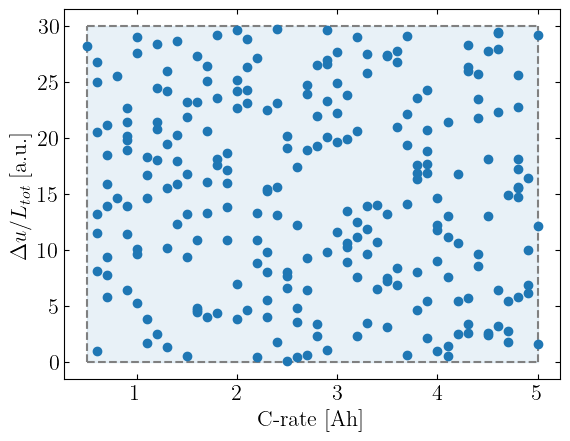

In [30]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C','trajectory']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

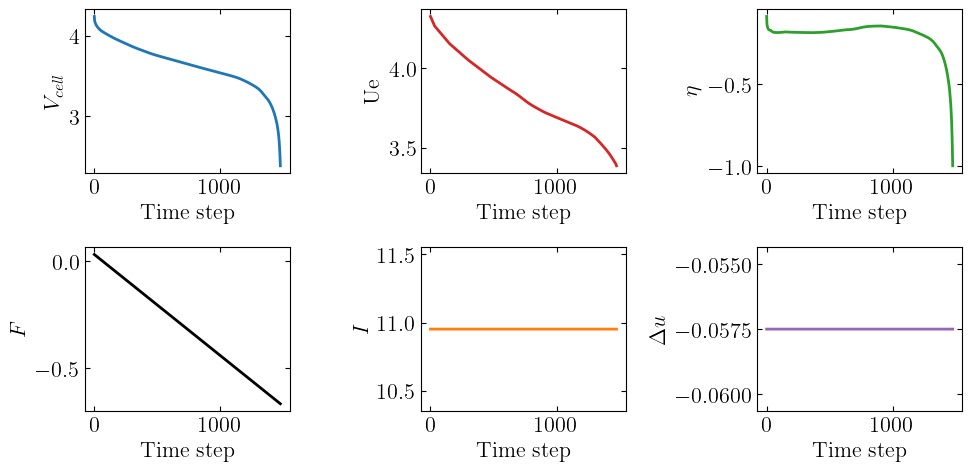

In [47]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

In [26]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['I', 'u', 'soc']].values
    Y_R1 = d_frame['R1'].values
    Y_C1 = d_frame['C1'].values
    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds], Y_R1[inds], Y_C1[inds]

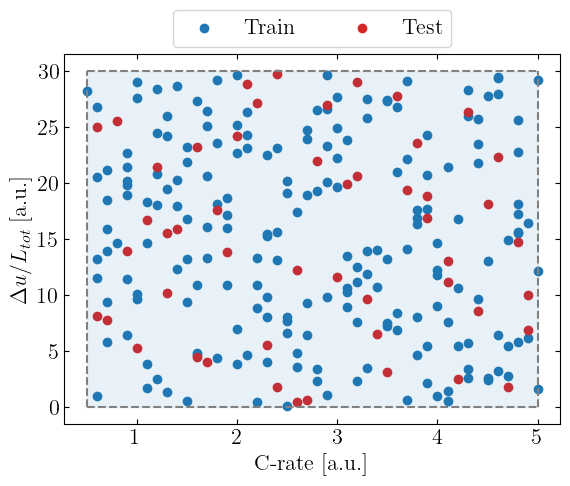

In [48]:
split_train = int(data['trajectory'].max() * 0.8)
data_train = data[data['trajectory'] <= split_train]
data_test = data[data['trajectory'] > split_train]

# X_train, YR_train, YC_train = get_XY(data_train)

# X_test, YR_test, YC_test = get_XY(data_test)


u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
plt.xlabel('C-rate [a.u.]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


# $R_1 = f_R(i,u,\mathrm{SOC})$

In [ ]:
def print_models(df_model):
    for i in range(len(df_model)):
        print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
        print(f"Equation: {df_model['equation'][i]}\n")

def print_best_model(model, model_index = None):
    best = model.get_best()
    display(Math(f'\\LARGE {model.latex(model_index)}'))
    print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [ ]:
# Parity plot
def pareto_plot(df_model, X_test = X_test, YR_test = YR_test, YC_test = YC_test):
    plt.scatter(df_model['complexity'], df_model['loss'])
    plt.xlabel('Complexity')
    plt.ylabel('Loss')
    plt.title('Model Complexity vs Loss')
    plt.show()

def parity_plot(element,modelR,modelC, X_test = X_test, YR_test = YR_test, YC_test = YC_test):
    if element == 'R1':
        Y_test = YR_test
        model = modelR
    elif element == 'C1':
        Y_test = YC_test
        model = modelC

    Y_pred = model.predict(X_test)
    plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.7)
    plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
    plt.xlabel(f'Actual ${element}$ [a.u.]')
    plt.ylabel(f'Predicted ${element}$ [a.u.]')
    plt.show()

def save_expressions(df_model, element):
    df_model.to_csv(f'model_{element}.csv', index=False)

NameError: name 'X_test' is not defined

In [ ]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR_train, model = None,run_id = 'R1')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [ ]:
df_model_R1 = model_R1.equations_

In [ ]:
#df_model_R1.to_csv('model_R1.csv', index=False)
#df_model_C1.to_csv('model_C1.csv', index=False)

# $C_1 = f_C(i,u,\mathrm{SOC})$

In [ ]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = 'R1')

In [ ]:
df_model_C1 = model_C1.equations_